In [1]:
# 1. Implement a simple GAN architecture to generate random images (like noise or basic shapes) using TensorFlow/Keras

import tensorflow as tf
from tensorflow.keras import layers

def build_generator(input_dim):
    model = tf.keras.Sequential()
    model.add(layers.Dense(128, activation='relu', input_dim=input_dim))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(28*28, activation='tanh'))
    model.add(layers.Reshape((28, 28)))
    return model

def build_discriminator(input_shape):
    model = tf.keras.Sequential()
    model.add(layers.Flatten(input_shape=input_shape))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

input_dim = 100
generator = build_generator(input_dim)
discriminator = build_discriminator((28, 28))

generator.summary()
discriminator.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          12,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │         402,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 583,312 (2.23 MB)

 Trainable params: 581,520 (2.22 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [2]:
# 2. Implement the discriminator for a GAN with an image input of shape (28, 28)

discriminator = build_discriminator((28, 28))
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
discriminator.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 0, Discriminator Loss: 0.9481958746910095, Generator Loss: [array(0.899136, dtype=float32), array(0.899136, dtype=float32), array(0.25, dtype=float32)]


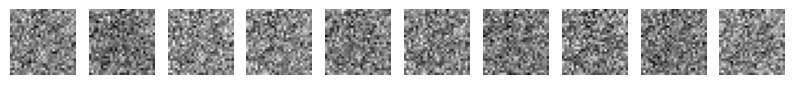

Epoch 100, Discriminator Loss: 0.31915274262428284, Generator Loss: [array(0.321464, dtype=float32), array(0.321464, dtype=float32), array(0.86695546, dtype=float32)]


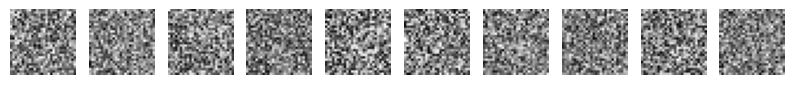

Epoch 200, Discriminator Loss: 0.4488734304904938, Generator Loss: [array(0.45055154, dtype=float32), array(0.45055154, dtype=float32), array(0.79329914, dtype=float32)]


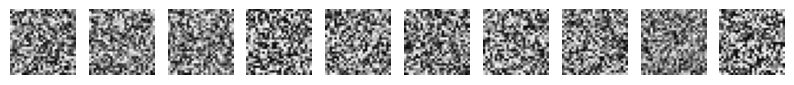

Epoch 300, Discriminator Loss: 0.5172079801559448, Generator Loss: [array(0.51813287, dtype=float32), array(0.51813287, dtype=float32), array(0.74906564, dtype=float32)]


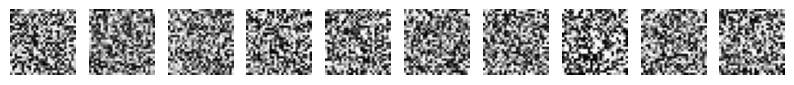

Epoch 400, Discriminator Loss: 0.562968373298645, Generator Loss: [array(0.56448567, dtype=float32), array(0.56448567, dtype=float32), array(0.7291926, dtype=float32)]


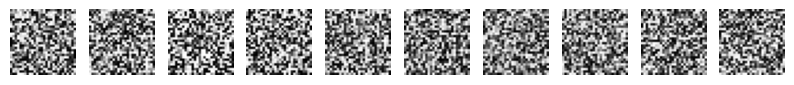

Epoch 500, Discriminator Loss: 0.6016113758087158, Generator Loss: [array(0.60224676, dtype=float32), array(0.60224676, dtype=float32), array(0.7149139, dtype=float32)]


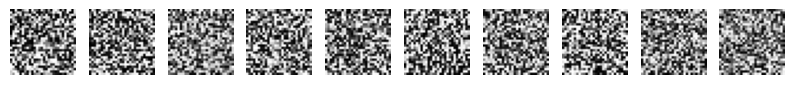

Epoch 600, Discriminator Loss: 0.6378383636474609, Generator Loss: [array(0.6382724, dtype=float32), array(0.6382724, dtype=float32), array(0.703073, dtype=float32)]


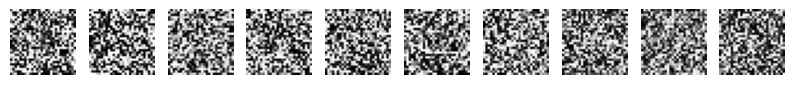

Epoch 700, Discriminator Loss: 0.661005973815918, Generator Loss: [array(0.66150993, dtype=float32), array(0.66150993, dtype=float32), array(0.69452125, dtype=float32)]


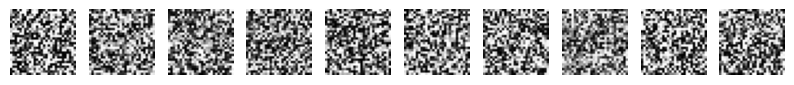

Epoch 800, Discriminator Loss: 0.6744455099105835, Generator Loss: [array(0.67470104, dtype=float32), array(0.67470104, dtype=float32), array(0.6893336, dtype=float32)]


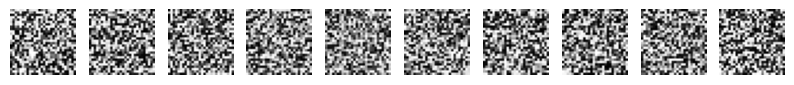

In [ ]:
# 3. Train the generator to produce simple digits (using noise as input) and plot the generated images

import matplotlib.pyplot as plt

def train_gan(generator, discriminator, epochs, batch_size, input_dim):
    gan = tf.keras.Sequential([generator, discriminator])
    discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    gan.compile(optimizer='adam', loss='binary_crossentropy')

    for epoch in range(epochs):
        noise = tf.random.normal([batch_size, input_dim])
        generated_images = generator(noise)

        real_images = tf.random.normal([batch_size, 28, 28])
        labels_real = tf.ones((batch_size, 1))
        labels_fake = tf.zeros((batch_size, 1))

        d_loss_real = discriminator.train_on_batch(real_images, labels_real)
        d_loss_fake = discriminator.train_on_batch(generated_images, labels_fake)

        noise = tf.random.normal([batch_size, input_dim])
        misleading_labels = tf.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, misleading_labels)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Discriminator Loss: {d_loss_real[0]}, Generator Loss: {g_loss}")
            plot_generated_images(generator, input_dim)

def plot_generated_images(generator, input_dim, examples=10):
    noise = tf.random.normal([examples, input_dim])
    generated_images = generator(noise)
    plt.figure(figsize=(10, 1))
    for i in range(examples):
        plt.subplot(1, examples, i+1)
        plt.imshow(generated_images[i, :, :], cmap='gray')
        plt.axis('off')
    plt.show()

input_dim = 100
train_gan(generator, discriminator, epochs=1000, batch_size=32, input_dim=input_dim)


In [ ]:
# 4. Implement WGAN by modifying the loss function in the GAN

import tensorflow as tf
from tensorflow.keras import layers

def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

discriminator.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.00005), loss=wasserstein_loss)
discriminator.summary()


In [ ]:
# 5. Use a trained generator to generate a batch of fake images and display them

def generate_and_display_images(generator, input_dim, examples=10):
    noise = tf.random.normal([examples, input_dim])
    generated_images = generator(noise)
    plt.figure(figsize=(10, 1))
    for i in range(examples):
        plt.subplot(1, examples, i+1)
        plt.imshow(generated_images[i, :, :], cmap='gray')
        plt.axis('off')
    plt.show()

generate_and_display_images(generator, input_dim, examples=10)

In [ ]:
# 6. Create a StyleGAN-inspired architecture that outputs high-resolution images

def build_stylegan_generator(input_dim):
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*512, activation='relu', input_dim=input_dim))
    model.add(layers.Reshape((8, 8, 512)))
    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(3, (3, 3), activation='tanh', padding='same'))
    return model

stylegan_generator = build_stylegan_generator(input_dim)
stylegan_generator.summary()


In [ ]:
# 8. Write a function to modify the discriminator to include a dropout layer with a rate of 0.4 and print the configurations

def modify_discriminator_with_dropout(input_shape, dropout_rate=0.4):
    model = tf.keras.Sequential()
    model.add(layers.Flatten(input_shape=input_shape))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

discriminator_with_dropout = modify_discriminator_with_dropout((28, 28))
discriminator_with_dropout.summary()
